In [2]:
# uv 프로젝트 환경이 있으면 uv sync로 의존성 설치 (권장)
!pip install numpy pandas matplotlib seaborn scipy scikit-learn statsmodels pingouin scikit_posthocs xgboost unidecode geopandas -q
print("pip 설치 완료!")

pip 설치 완료!



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\82105\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [3]:
# ============================================================
# 라이브러리 Import
# ============================================================

# 데이터 처리 및 분석
import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings
from unidecode import unidecode
import geopandas as gpd

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from scipy.stats import skew, kurtosis
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg
import scikit_posthocs as sp


# 머신러닝
from sklearn.preprocessing import MinMaxScaler

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)



라이브러리 로드 완료!
한글 폰트 설정 완료!


In [4]:
df_merge = pd.read_csv('../data/olist_preprocess_ver2_data.csv')
df_location = pd.read_csv('../data/geolocation_clean.csv')
print('데이터 로드 완료')

데이터 로드 완료


In [46]:
df = df_merge.copy()
geo = df_location.copy()

In [47]:
# 날짜 칼럼 변환
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'shipping_limit_date',
    'review_creation_date'
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors='coerce')

df = df[
    (df['order_delivered_customer_date'] != pd.Timestamp('2099-01-01')) &  #두 조건 동일행 의미
    (df['order_status'] == 'delivered')
]
# removed rows: 1881
# remaining rows: 10961

In [48]:
# 배송 지연 계산 (핵심 타겟)
# 배송 지연 일수 계산
df['delivery_delay_days'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days
df = df[(df['delivery_delay_days'] > 0) & (df['delivery_delay_days'] < 100)]
df['is_delayed'] = (df['delivery_delay_days'] > 0).astype(int)

In [49]:
df['delivery_delay_days'].sort_values()

85258     1
85237     1
96614     1
85475     1
84483     1
         ..
15233    96
36025    96
20973    96
31747    96
65498    97
Name: delivery_delay_days, Length: 7211, dtype: int64

In [8]:
# 컬럼명은 실제 데이터에 맞게 수정
# 예시: seller_state, customer_state, delay_days

# 1. 판매자 state별 평균 배송 지연
seller_delay = df.groupby('seller_state')['delivery_delay_days'].mean().sort_values(ascending=False)
print(seller_delay)


seller_state
AM    38.000000
GO    13.307692
CE    12.500000
SC    12.324742
PR    11.970982
ES    11.285714
BA    10.851852
MG    10.599502
RS    10.463768
RJ    10.403727
RN     9.750000
SP     9.363243
DF     8.849057
MA     7.679487
PE     7.600000
MS     7.333333
MT     6.666667
PB     2.000000
Name: delivery_delay_days, dtype: float64


In [9]:
# 2. 구매자 state별 평균 배송 지연
buyer_delay = df.groupby('customer_state')['delivery_delay_days'].mean().sort_values(ascending=False)
print(buyer_delay)


customer_state
AC    18.666667
CE    13.588542
RJ    12.902990
RR    12.500000
RN    11.673913
PA    11.228814
PE    11.025316
BA    10.315545
MT    10.269841
PB    10.080645
AL     9.727273
GO     9.656934
SE     9.559322
RS     9.543662
ES     9.186441
MA     9.000000
SC     8.862687
PI     8.550725
PR     8.095890
MS     7.972603
MG     7.969751
DF     7.893617
SP     7.659941
TO     6.566667
RO     6.454545
AM     4.500000
AP     1.000000
Name: delivery_delay_days, dtype: float64


In [10]:
# 3. 판매자 + 구매자 state 조합별 평균 배송 지연
combo_delay = df.groupby(['seller_state', 'customer_state'])['delivery_delay_days'].mean().reset_index()
combo_delay = combo_delay.sort_values('delivery_delay_days', ascending=False)
print(combo_delay.head(20))

    seller_state customer_state  delivery_delay_days
0             AM             AL            38.000000
166           SC             GO            32.500000
42            GO             RJ            31.333333
78            MG             PI            31.000000
33            ES             PA            25.000000
1             BA             AC            24.000000
164           SC             CE            23.500000
163           SC             BA            23.444444
16            CE             RJ            23.000000
151           RS             DF            22.000000
17            DF             BA            22.000000
56            MA             PB            22.000000
138           RJ             RN            21.333333
146           RN             CE            20.000000
18            DF             CE            18.500000
133           RJ             PA            18.000000
126           RJ             DF            17.750000
70            MG             GO            17.

In [15]:
combo_delay.shape

(209, 3)

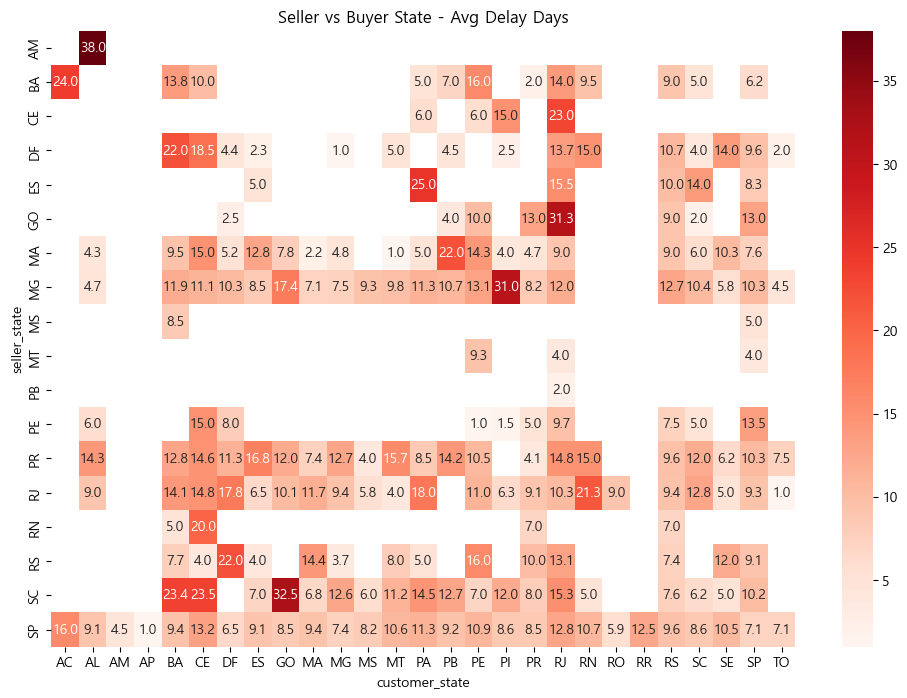

In [11]:
# 히트맵 - 조합별 지연일수 한눈에 보기
pivot = combo_delay.pivot(index='seller_state', columns='customer_state', values='delivery_delay_days')
plt.figure(figsize=(12, 8))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='Reds')
plt.title('Seller vs Buyer State - Avg Delay Days')
plt.show()

In [12]:
groups = [group['delivery_delay_days'].values for _, group in df.groupby(['seller_state', 'customer_state'])]

# 정규성 검정 (Shapiro-Wilk)
stat_s, p_s = shapiro(df['delivery_delay_days'])
print(f'정규성 p-value: {p_s:.20f}') 

# 등분산성 검정 (Levene)
stat_l, p_l = levene(*groups)
print(f'등분산성 p-value: {p_l:.10f}')

#정규성 p-value=0 -> 분포 자체가 너무 비정규적이기 때문에 이러한 값이 나옴 문제 없음
#정규성 < 0.05 -> 정규성 불만족
#등분산성 p-value=0.000023
#등분산성 불충족

# 정규성 x, 등분산성 x -> kruskal-wallis(KW) 사용

정규성 p-value: 0.00000000000000000000
등분산성 p-value: 0.0000000000


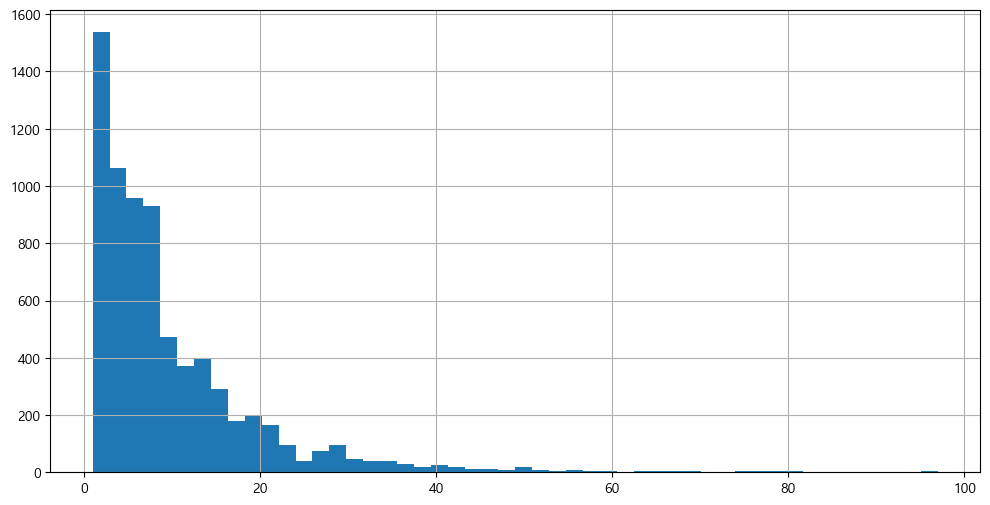

In [18]:
df['delivery_delay_days'].hist(bins=50)
plt.show()

In [13]:
# 집단 수 (셀러-구매자 조합 수)
print(df.groupby(['seller_state', 'customer_state']).ngroups)

# 전체 표본 크기
print(len(df))

209
7211


In [14]:
# TODO: Kruskal-Wallis 검정 수행 (stats.kruskal)

stat_kw, p_kw = stats.kruskal(*groups)
print(f"  H 통계량: {stat_kw:.4f}")
print(f"  p-value: {p_kw:.20f}")

# TODO: η²_H 효과크기 계산
# 공식: η²_H = (H − k + 1) / (N − k)  (k=집단수, N=전체 표본 크기)
k = 209
N = 7211
eta_sq_h = (stat_kw - k + 1) / (N - k)

print(eta_sq_h)

  H 통계량: 667.5257
  p-value: 0.00000000000000000000
0.06562778170190738


In [ ]:
# #사후검정 Dunn

# valid_seller = df.groupby('seller_state')['delivery_delay_days'].count()
# valid_seller = valid_seller[valid_seller >= 10].index
# df_seller_filtered = df[df['seller_state'].isin(valid_seller)]

# # 3. Dunn's test
# result_seller = sp.posthoc_dunn(df_seller_filtered, val_col='delivery_delay_days', group_col='seller_state', p_adjust='fdr_bh')
# display(result_seller)

# # 4. 유의미한 쌍만 추출
# sig_seller = result_seller.stack().reset_index()
# sig_seller.columns = ['state1', 'state2', 'p_value']
# sig_seller = sig_seller[(sig_seller['p_value'].notna()) & (sig_seller['p_value'] < 0.05) & (sig_seller['state1'] != sig_seller['state2'])]
# print(sig_seller.sort_values('p_value'))

# # customer_state별 사후검정
# result_customer = sp.posthoc_dunn(df, val_col='delivery_delay_days', group_col='customer_state', p_adjust='fdr_bh')
# display(result_customer)



,BA,DF,ES,GO,MA,MG,PE,PR,RJ,RS,SC,SP
BA,1.000000,0.656843,0.657061,0.822064,0.656843,0.814831,0.656843,0.904160,0.739479,0.979917,0.889208,0.657061
DF,0.656843,1.000000,0.904160,0.656843,0.814831,0.656843,0.904160,0.432078,0.656843,0.656843,0.656843,0.656843
ES,0.657061,0.904160,1.000000,0.656843,0.904160,0.711919,0.879233,0.656843,0.795035,0.656843,0.656843,0.822064
GO,0.822064,0.656843,0.656843,1.000000,0.656843,0.711919,0.656843,0.827842,0.656843,0.814831,0.752157,0.656843
MA,0.656843,0.814831,0.904160,0.656843,1.000000,0.656843,0.819403,0.543736,0.739479,0.656843,0.656843,0.814831
MG,0.814831,0.656843,0.711919,0.711919,0.656843,1.000000,0.656843,0.656843,0.739479,0.739479,0.814831,0.656843
PE,0.656843,0.904160,0.879233,0.656843,0.819403,0.656843,1.000000,0.656843,0.711919,0.656843,0.656843,0.739479
PR,0.904160,0.432078,0.656843,0.827842,0.543736,0.656843,0.656843,1.000000,0.432078,0.879233,0.686180,0.001350
RJ,0.739479,0.656843,0.795035,0.656843,0.739479,0.739479,0.711919,0.432078,1.000000,0.656843,0.656843,0.739479
RS,0.979917,0.656843,0.656843,0.814831,0.656843,0.739479,0.656843,0.879233,0.656843,1.000000,0.878964,0.656843


    state1 state2  p_value
95      PR     SP  0.00135
139     SP     PR  0.00135


,AC,AL,AM,AP,BA,CE,DF,ES,GO,MA,MG,MS,MT,PA,PB,PE,PI,PR,RJ,RN,RO,RR,RS,SC,SE,SP,TO
AC,1.000000,0.658759,0.255488,0.233918,6.461774e-01,8.808127e-01,3.963098e-01,0.493723,0.527240,0.525995,4.057094e-01,0.435089,0.696764,8.094113e-01,0.595561,7.585643e-01,0.481777,3.822879e-01,8.308179e-01,0.796729,0.476691,0.925527,6.480943e-01,4.766909e-01,0.734262,3.418568e-01,0.395753
AL,0.658759,1.000000,0.239375,0.260852,9.204505e-01,1.511014e-01,9.111375e-02,0.325282,0.473279,0.461452,5.430758e-02,0.243626,0.849533,3.822879e-01,0.786461,5.889786e-01,0.377223,3.775684e-02,2.136237e-01,0.548140,0.548140,0.698742,9.628069e-01,2.469165e-01,0.766684,1.751291e-03,0.256675
AM,0.255488,0.239375,1.000000,0.648094,2.393747e-01,1.050880e-01,4.389469e-01,0.341857,0.322706,0.323031,4.094110e-01,0.405709,0.231379,1.511014e-01,0.279641,1.902638e-01,0.370718,4.614517e-01,1.322660e-01,0.174278,0.473279,0.255488,2.359842e-01,3.605882e-01,0.213624,5.142664e-01,0.487555
AP,0.233918,0.260852,0.648094,1.000000,2.612244e-01,1.992764e-01,3.682774e-01,0.319789,0.308217,0.308217,3.605882e-01,0.352018,0.249982,2.272433e-01,0.281615,2.359842e-01,0.325282,3.740050e-01,2.150526e-01,0.232112,0.370718,0.235984,2.608521e-01,3.237170e-01,0.242762,3.934912e-01,0.381107
BA,0.646177,0.920451,0.239375,0.261224,1.000000e+00,9.290753e-03,1.365689e-02,0.171069,0.377223,0.365661,2.539012e-04,0.171428,0.771307,2.136237e-01,0.795147,3.739680e-01,0.316393,1.081958e-03,8.589649e-04,0.438538,0.552416,0.679611,9.302314e-01,5.430758e-02,0.648094,6.134710e-12,0.232112
CE,0.880813,0.151101,0.105088,0.199276,9.290753e-03,1.000000e+00,3.687649e-06,0.000102,0.002682,0.002182,9.633356e-10,0.001230,0.297588,5.955609e-01,0.098122,3.045992e-01,0.006517,2.348591e-08,5.553361e-01,0.648094,0.235984,0.970162,1.482803e-02,5.623192e-06,0.382288,3.443014e-17,0.013216
DF,0.396310,0.091114,0.438947,0.368277,1.365689e-02,3.687649e-06,1.000000e+00,0.370718,0.316393,0.316393,8.643978e-01,0.820607,0.079155,1.081958e-03,0.260852,2.682307e-03,0.599005,8.700438e-01,9.638126e-08,0.032725,0.919011,0.396310,1.365689e-02,4.104523e-01,0.054308,4.464979e-01,0.909237
ES,0.493723,0.325282,0.341857,0.319789,1.710688e-01,1.021809e-04,3.707179e-01,1.000000,0.816846,0.826479,3.082168e-01,0.648094,0.277056,1.289285e-02,0.599005,3.582437e-02,0.880813,2.321122e-01,1.287473e-06,0.151101,0.831748,0.511958,1.637384e-01,8.495326e-01,0.232112,5.881745e-03,0.543167
GO,0.527240,0.473279,0.322706,0.308217,3.772229e-01,2.682307e-03,3.163934e-01,0.816846,1.000000,0.986884,2.647926e-01,0.542712,0.393491,5.648836e-02,0.766684,1.435056e-01,0.778753,2.136237e-01,1.334385e-03,0.235984,0.785808,0.548140,3.656609e-01,6.884018e-01,0.330369,1.476214e-02,0.473279
MA,0.525995,0.461452,0.323031,0.308217,3.656609e-01,2.181976e-03,3.163934e-01,0.826479,0.986884,1.000000,2.647926e-01,0.544991,0.383565,5.430758e-02,0.758564,1.322660e-01,0.785808,2.136237e-01,1.081958e-03,0.232112,0.786461,0.548140,3.479179e-01,6.941037e-01,0.323717,1.366404e-02,0.476691


In [58]:
# 최소 샘플 필터
valid = df.groupby('seller_state')['delivery_delay_days'].count()
valid = valid[valid >= 10].index
df_filtered = df[df['seller_state'].isin(valid)]

# Dunn test
result = sp.posthoc_dunn(
    df_filtered,
    val_col='delivery_delay_days',
    group_col='seller_state',
    p_adjust='fdr_bh'
)

# 유의 pair
sig = (
    result.stack()
    .reset_index()
)

sig.columns = ['state1','state2','p']

sig = sig[
    (sig['state1'] < sig['state2']) &
    (sig['p'] < 0.05)
]

sig.sort_values('p')

,state1,state2,p
95,PR,SP,0.00135


In [26]:
# 각 seller_state별 데이터 수 확인
print(df.groupby('seller_state')['delivery_delay_days'].count())

seller_state
AM       1
BA      27
CE       4
DF      53
ES      21
GO      13
MA      78
MG     402
MS       3
MT       6
PB       1
PE      15
PR     448
RJ     322
RN       4
RS      69
SC     194
SP    5550
Name: delivery_delay_days, dtype: int64


In [29]:
combo_delay2 = df.groupby(['seller_state', 'customer_state'])['delivery_delay_days'].agg(['mean', 'count']).reset_index()
combo_delay2.columns = ['seller_state', 'customer_state', 'avg_delay', 'count']
combo_delay2 = combo_delay2.sort_values('avg_delay', ascending=False)
print(combo_delay2.head(20))

    seller_state customer_state  avg_delay  count
0             AM             AL  38.000000      1
166           SC             GO  32.500000      4
42            GO             RJ  31.333333      3
78            MG             PI  31.000000      1
33            ES             PA  25.000000      1
1             BA             AC  24.000000      1
164           SC             CE  23.500000      4
163           SC             BA  23.444444      9
16            CE             RJ  23.000000      1
151           RS             DF  22.000000      2
17            DF             BA  22.000000      2
56            MA             PB  22.000000      1
138           RJ             RN  21.333333      3
146           RN             CE  20.000000      1
18            DF             CE  18.500000      4
133           RJ             PA  18.000000      2
126           RJ             DF  17.750000     12
70            MG             GO  17.400000      5
106           PR             ES  16.777778      9


In [15]:

# 같은 state 여부 변수 생성
df['same_state_str'] = df['seller_state'] == df['customer_state']

same = df[df['same_state_str']]['delivery_delay_days']
diff = df[~df['same_state_str']]['delivery_delay_days']

stat, p = mannwhitneyu(same, diff, alternative='two-sided')

print("Mann-Whitney U:", stat)
print("p-value:", p)

print("같은 state 평균:", same.mean())
print("다른 state 평균:", diff.mean())

#p: 0에 매우 가까움 -> 귀무가설 기각

Mann-Whitney U: 3546499.0
p-value: 1.1258266405576404e-61
같은 state 평균: 7.1610890527509925
다른 state 평균: 10.555066079295154


In [16]:
df['state_pair'] = df['seller_state'] + "_" + df['customer_state']

pair_count = df['state_pair'].value_counts()
valid_pairs = pair_count[pair_count >= 30].index

df_pair_filtered = df[df['state_pair'].isin(valid_pairs)]

In [17]:
from scipy.stats import kruskal

groups2 = [
    group['delivery_delay_days'].values
    for name, group in df_pair_filtered.groupby('state_pair')
]

stat, p = kruskal(*groups2)

print("Kruskal H:", stat)
print("p-value:", p)

#p=0 -> 귀무가설 기각

Kruskal H: 460.8628732960803
p-value: 1.886333980174936e-77


In [18]:
import scikit_posthocs as sp

dunn_result = sp.posthoc_dunn(
    df_pair_filtered,
    val_col='delivery_delay_days',
    group_col='state_pair',
    p_adjust='fdr_bh'
)

display(dunn_result)

,MG_BA,MG_MG,MG_RJ,MG_SP,PR_MG,PR_RJ,PR_SP,RJ_MG,RJ_RJ,RJ_SP,SC_RJ,SC_SP,SP_AL,SP_BA,SP_CE,SP_DF,SP_ES,SP_GO,SP_MA,SP_MG,SP_MS,SP_MT,SP_PA,SP_PB,SP_PE,SP_PI,SP_PR,SP_RJ,SP_RN,SP_RS,SP_SC,SP_SE,SP_SP
MG_BA,1.000000,0.232821,9.398568e-01,0.320237,0.969614,4.001762e-01,0.269384,0.425164,0.123305,0.438587,0.750163,0.883311,0.849607,5.697298e-01,6.850383e-01,5.125538e-02,0.350604,0.317329,0.545015,9.120336e-02,0.314095,0.991576,7.638257e-01,0.488541,9.960296e-01,0.448176,1.036465e-01,6.023200e-01,0.939857,7.724952e-01,3.067978e-01,0.871428,9.966800e-03
MG_MG,0.232821,1.000000,9.120336e-02,0.711431,0.245958,5.301879e-03,0.793260,0.763826,0.875950,0.544721,0.071743,0.274467,0.274467,3.237885e-01,2.472940e-02,7.367704e-01,0.581597,0.697551,0.425164,9.969044e-01,0.812865,0.179483,4.803392e-02,0.682460,1.110014e-01,0.639342,9.696144e-01,7.916923e-03,0.275447,1.978311e-01,6.368206e-01,0.119967,5.364375e-01
MG_RJ,0.939857,0.091203,1.000000e+00,0.098473,0.912864,2.812586e-01,0.066816,0.269384,0.028094,0.192502,0.761213,0.748859,0.690504,2.658671e-01,6.485589e-01,1.941764e-03,0.091203,0.091203,0.310330,1.540605e-03,0.121848,0.946864,7.682975e-01,0.323789,9.323273e-01,0.253396,5.325760e-03,4.844084e-01,0.875950,5.135624e-01,5.559158e-02,0.911246,7.195479e-07
MG_SP,0.320237,0.711431,9.847321e-02,1.000000,0.333981,1.527237e-03,0.932327,0.993866,0.503575,0.814542,0.085772,0.364823,0.364823,4.425031e-01,1.188717e-02,2.826470e-01,0.879351,0.993866,0.612034,5.090320e-01,0.939857,0.253396,4.286565e-02,0.931656,1.231457e-01,0.907308,5.179883e-01,7.829878e-04,0.365974,2.459581e-01,9.398568e-01,0.154745,5.331385e-02
PR_MG,0.969614,0.245958,9.128642e-01,0.333981,1.000000,3.484030e-01,0.278244,0.448364,0.129759,0.466457,0.697228,0.925736,0.883979,6.032536e-01,6.243542e-01,5.234240e-02,0.363467,0.331423,0.582159,9.246795e-02,0.327267,0.946864,7.044452e-01,0.513562,9.499402e-01,0.475702,1.081765e-01,5.337671e-01,0.973062,8.194272e-01,3.208735e-01,0.822713,9.587051e-03
PR_RJ,0.400176,0.005302,2.812586e-01,0.001527,0.348403,1.000000e+00,0.000618,0.035015,0.000618,0.004785,0.664155,0.196354,0.143749,2.388976e-03,5.337671e-01,1.201541e-06,0.000479,0.001071,0.012034,2.930069e-08,0.004244,0.363282,5.179883e-01,0.050021,1.997223e-01,0.017992,2.451971e-06,4.962063e-01,0.336929,1.988700e-02,1.003383e-04,0.545015,6.239399e-15
PR_SP,0.269384,0.793260,6.681624e-02,0.932327,0.278244,6.177571e-04,1.000000,0.939082,0.561090,0.697551,0.060739,0.316654,0.314095,3.339811e-01,5.733098e-03,3.415799e-01,0.761213,0.926207,0.517309,6.023200e-01,0.996723,0.196627,2.494890e-02,0.864829,8.349308e-02,0.819427,6.059616e-01,1.964031e-04,0.326090,1.573666e-01,8.484811e-01,0.121848,7.735573e-02
RJ_MG,0.425164,0.763826,2.693836e-01,0.993866,0.448364,3.501496e-02,0.939082,1.000000,0.589174,0.883311,0.196257,0.513223,0.517988,6.485589e-01,1.094721e-01,4.425031e-01,0.932327,0.996723,0.748859,6.737198e-01,0.939857,0.364823,1.573666e-01,0.939857,3.103297e-01,0.932327,6.612072e-01,6.073947e-02,0.488541,4.757025e-01,9.730622e-01,0.277990,2.693836e-01
RJ_RJ,0.123305,0.875950,2.809360e-02,0.503575,0.129759,6.177571e-04,0.561090,0.589174,1.000000,0.343161,0.024949,0.139689,0.137003,1.372788e-01,3.934137e-03,9.213364e-01,0.354900,0.487563,0.246509,8.128648e-01,0.602320,0.087471,1.089878e-02,0.513562,3.501496e-02,0.449525,8.704484e-01,6.177571e-04,0.154271,7.174319e-02,3.921523e-01,0.052369,7.152281e-01
RJ_SP,0.438587,0.544721,1.925016e-01,0.814542,0.466457,4.785457e-03,0.697551,0.883311,0.343161,1.000000,0.143728,0.528725,0.533767,6.901375e-01,3.501496e-02,1.428268e-01,0.931656,0.816410,0.848481,2.693836e-01,0.752574,0.363222,9.097310e-02,0.946864,2.381263e-01,0.946864,3.140952e-01,3.426321e-03,0.513562,4.249594e-01,8.403742e-01,0.254102,9.726723e-03


In [19]:
sig_pairs = (
    dunn_result
    .stack()
    .reset_index()
)

sig_pairs.columns = ['pair1', 'pair2', 'p_value']

sig_pairs = sig_pairs[
    (sig_pairs['pair1'] < sig_pairs['pair2']) &
    (sig_pairs['p_value'] < 0.05)
]

sig_pairs = sig_pairs.sort_values('p_value')

print(sig_pairs)

     pair1  pair2       p_value
923  SP_RJ  SP_SP  3.769316e-72
654  SP_MG  SP_RJ  2.398981e-19
197  PR_RJ  SP_SP  6.239399e-15
494  SP_CE  SP_SP  6.004628e-13
989  SP_RS  SP_SP  6.423143e-10
..     ...    ...           ...
455  SP_BA  SP_PR  4.286565e-02
121  MG_SP  SP_PA  4.286565e-02
411  SP_AL  SP_DF  4.286565e-02
648  SP_MG  SP_MT  4.574513e-02
55   MG_MG  SP_PA  4.803392e-02

[102 rows x 3 columns]


In [20]:
pair_delay = (
    df_pair_filtered
    .groupby('state_pair')['delivery_delay_days']
    .agg(['count','mean','median'])
    .sort_values('mean', ascending=False)
)

print(pair_delay.head(20))

            count       mean  median
state_pair                          
SC_RJ          49  15.265306    12.0
PR_RJ         124  14.766129    12.0
SP_CE         149  13.234899     9.0
SP_RJ        1265  12.765217     9.0
PR_MG          38  12.710526     7.5
MG_RJ         101  11.970297     8.0
MG_BA          35  11.885714     7.0
SP_PA          90  11.288889     8.5
SP_PE         114  10.929825     8.0
SP_RN          35  10.685714     8.0
SP_MT          46  10.630435     7.0
SP_SE          42  10.452381     8.0
MG_SP          99  10.323232     6.0
RJ_RJ          49  10.306122     5.0
PR_SP         106  10.301887     5.0
SC_SP          52  10.192308     7.0
SP_RS         258   9.620155     8.0
RJ_MG          36   9.444444     5.0
SP_BA         332   9.409639     7.0
SP_MA         108   9.370370     7.5


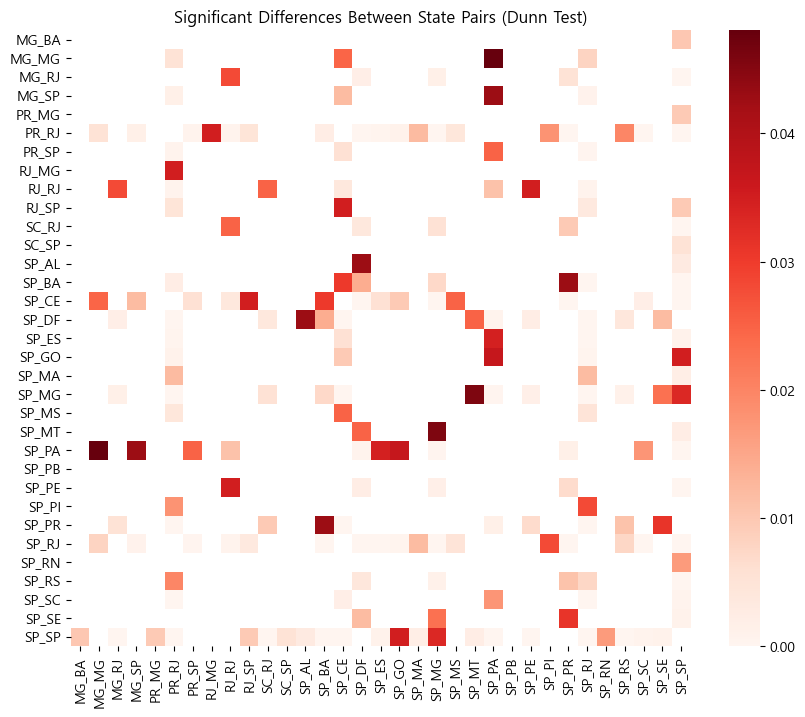

In [21]:
import numpy as np

sig_matrix = dunn_result.copy()

# 유의하지 않은 값 제거
sig_matrix[sig_matrix >= 0.05] = np.nan

plt.figure(figsize=(10,8))

sns.heatmap(
    sig_matrix,
    annot=False,
    cmap="Reds",
    mask=sig_matrix.isna()
)

plt.title("Significant Differences Between State Pairs (Dunn Test)")
plt.show()

In [22]:
# 이건 미리 실행돼 있어야 함
df['estimated_days'] = (df['order_estimated_delivery_date'] - df['order_purchase_timestamp']).dt.days

# 1. 주문부터 승인까지 걸린 시간
df['approval_time'] = (df['order_approved_at'] - df['order_purchase_timestamp']).dt.days

# 3. 상품 부피
df['product_volume'] = df['product_length_cm'] * df['product_height_cm'] * df['product_width_cm']

# 4. 주문 월, 요일 (계절성)
df['order_month'] = df['order_purchase_timestamp'].dt.month
df['order_dayofweek'] = df['order_purchase_timestamp'].dt.dayofweek

In [ ]:

# 지리적 정보 병합 및 거리 계산
# 하버사인 공식으로 두 점 사이의 거리 계산
def calculate_distance(lat1, lng1, lat2, lng2):
    R = 6371  # 지구의 반지름 (km)
    
    lat1_rad = np.radians(lat1)
    lng1_rad = np.radians(lng1)
    lat2_rad = np.radians(lat2)
    lng2_rad = np.radians(lng2)
    
    dlat = lat2_rad - lat1_rad
    dlng = lng2_rad - lng1_rad
    
    a = np.sin(dlat/2)**2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlng/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return R * c

# 고객 위치 좌표 병합
geo_customer = geo.groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean'
}).reset_index()

geo_customer.columns = ['customer_zip_code_prefix', 'customer_lat', 'customer_lng']
df_merged = df.merge(geo_customer, on='customer_zip_code_prefix', how='left')

# 판매자 위치 좌표 병합
geo_seller = geo.groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean'
}).reset_index()

geo_seller.columns = ['seller_zip_code_prefix', 'seller_lat', 'seller_lng']
df_merged = df_merged.merge(geo_seller, on='seller_zip_code_prefix', how='left')

# 각 주문에 대해 고객과 판매자 사이의 거리 계산
distances = []
for index, row in df_merged.iterrows():
    if pd.notna(row['seller_lat']) and pd.notna(row['customer_lat']):
        dist = calculate_distance(
            row['seller_lat'], row['seller_lng'],
            row['customer_lat'], row['customer_lng']
        )
        distances.append(dist)
    else:
        distances.append(None)

df_merged['actual_distance_km'] = distances

# 거리 정보가 없는 행 제거
df_merged = df_merged.dropna(subset=['actual_distance_km'])

In [ ]:
# Feature Engineering (update_0309)
# 거리 단위 로그 변환
df["distance_log"] = np.log1p(df["actual_distance_km"])

# 상품 밀도
df["volume_density"] = df["product_weight_g"]/(df["product_volume"]+1)

# 상품 대비 배송비 비율
df["freight_ratio"] = df["freight_value"]/(df["price"]+1)

# 배송 거리 대비 배송 속도
df["delivery_speed"] = df["actual_distance_km"]/(df["delivery_delay_days"].abs()+1)

# 판매자와 고객이 같은 주(state)에 있는지 여부 (t=1, f=0)
df["seller_customer_state_same"] = (
df["seller_state"]==df["customer_state"]
).astype(int)

# 겨울 시즌 배송 거리 효과를 따로 학습하기 위한 변수
# 겨울에는 같은 거리라도 배송 지연이 더 발생할까?
df["distance_winter"] = df["actual_distance_km"]*(df["season"]=="winter")

# 주문 시점부터 예상 배송일까지의 기간 (예상 배송 소요 일수)
df["estimated_delivery_gap"] = (
    df["order_estimated_delivery_date"]-
    df["order_purchase_timestamp"]
).dt.days

# 실제배송거리 대비 예상배송기간 비율 (거리/예상 배송일)
df["distance_gap_ratio"] = df["actual_distance_km"]/(df["estimated_delivery_gap"]+1)

# 배송비를 거리로 나눈 값 (km당 배송비)
df["freight_per_km"] = df["freight_value"]/(df["actual_distance_km"]+1)

# 상품부피 대비 배송거리 비율 (부피 / km)
df["volume_per_km"] = df["product_volume"]/(df["actual_distance_km"]+1)

# 상품무게 대비 배송거리 비율 (무게 / km)
df["weight_per_km"] = df["product_weight_g"]/(df["actual_distance_km"]+1)

# 상품가격 대비 무게비율 (무게 / 가격)
df["price_per_weight"] = df["price"]/(df["product_weight_g"]+1)

# 고객-판매자 거리 대비 배송비 비율 (거리 / 배송비)
df["customer_seller_distance_ratio"] = (
    df["actual_distance_km"]/(df["freight_value"]+1)
)

KeyError: 'actual_distance_km'

In [23]:
# 현재 분포 확인
print(df['delivery_delay_days'].describe())

# IQR로 극단치 제거
Q1 = df['delivery_delay_days'].quantile(0.25)
Q3 = df['delivery_delay_days'].quantile(0.75)
IQR = Q3 - Q1

df_clean = df[df['delivery_delay_days'].between(Q1 - 1.5*IQR, Q3 + 1.5*IQR)]

print(f'원본: {len(df)}행')
print(f'제거 후: {len(df_clean)}행')
print(df_clean['delivery_delay_days'].describe())

count    7211.000000
mean        9.725281
std        10.535435
min         1.000000
25%         3.000000
50%         7.000000
75%        13.000000
max        97.000000
Name: delivery_delay_days, dtype: float64
원본: 7211행
제거 후: 6828행
count    6828.000000
mean        7.889133
std         6.467177
min         1.000000
25%         3.000000
50%         6.000000
75%        11.000000
max        28.000000
Name: delivery_delay_days, dtype: float64


In [33]:
# 파생 변수 추가
df['same_state'] = (df['seller_state'] == df['customer_state']).astype(int)
df_clean['same_state'] = (df_clean['seller_state'] == df_clean['customer_state']).astype(int)

In [66]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 파생 변수 추가
df['same_state'] = (df['seller_state'] == df['customer_state']).astype(int)

features = [
    'seller_state',
    'customer_state',
    'same_state',
    'freight_value',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm',
    'product_category_name_english',
    'estimated_days',
    'approval_time',
    'product_volume',
    'order_month',
    'order_dayofweek'
]

cat_cols = ['seller_state', 'customer_state', 'product_category_name_english']
num_cols = ['same_state', 'freight_value', 'product_weight_g', 'product_length_cm',
            'product_height_cm', 'product_width_cm', 'estimated_days',
            'approval_time', 'product_volume', 'order_month', 'order_dayofweek']

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', 'passthrough', num_cols)
])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        random_state=42,
        n_jobs=-1))
])

X = df_clean[features].fillna(df_clean[features].median(numeric_only=True))
y = df_clean['delivery_delay_days']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print(f'MAE:  {mean_absolute_error(y_test, y_pred):.4f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}')
print(f'R²:   {r2_score(y_test, y_pred):.4f}')


MAE:  4.4257
RMSE: 6.0008
R²:   0.1629


In [51]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [5, 10, 20, None],
    'model__min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print(f'최적 파라미터: {grid_search.best_params_}')

# 최적 모델로 평가
y_pred_best = grid_search.best_estimator_.predict(X_test)
print(f'MAE:  {mean_absolute_error(y_test, y_pred_best):.4f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_best)):.4f}')
print(f'R²:   {r2_score(y_test, y_pred_best):.4f}')

Fitting 5 folds for each of 36 candidates, totalling 180 fits
최적 파라미터: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 300}
MAE:  4.4257
RMSE: 6.0008
R²:   0.1629


In [52]:
from xgboost import XGBRegressor

pipeline_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1))
])

X = df_clean[features].fillna(df_clean[features].median(numeric_only=True))
y = df_clean['delivery_delay_days']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline_xgb.fit(X_train, y_train)
y_pred_xgb = pipeline_xgb.predict(X_test)

print(f'MAE:  {mean_absolute_error(y_test, y_pred_xgb):.4f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_xgb)):.4f}')
print(f'R²:   {r2_score(y_test, y_pred_xgb):.4f}')

MAE:  4.7032
RMSE: 6.2005
R²:   0.1063


In [53]:
df_50 = df[(df['delivery_delay_days'] > 0) & (df['delivery_delay_days'] <= 50)]
print(f'행 수: {len(df_50)}')
print(df_50['delivery_delay_days'].describe())

행 수: 7135
count    7135.000000
mean        9.118430
std         8.678452
min         1.000000
25%         3.000000
50%         7.000000
75%        13.000000
max        50.000000
Name: delivery_delay_days, dtype: float64


estimated_days                                         0.114700
freight_value                                          0.114260
product_weight_g                                       0.090937
product_volume                                         0.083896
product_length_cm                                      0.067486
product_height_cm                                      0.062693
product_width_cm                                       0.062513
order_month                                            0.057054
order_dayofweek                                        0.053555
customer_state_RJ                                      0.029665
approval_time                                          0.022715
product_category_name_english_bed_bath_table           0.009714
product_category_name_english_sports_leisure           0.008454
product_category_name_english_health_beauty            0.008270
product_category_name_english_housewares               0.008234
seller_state_SP                         

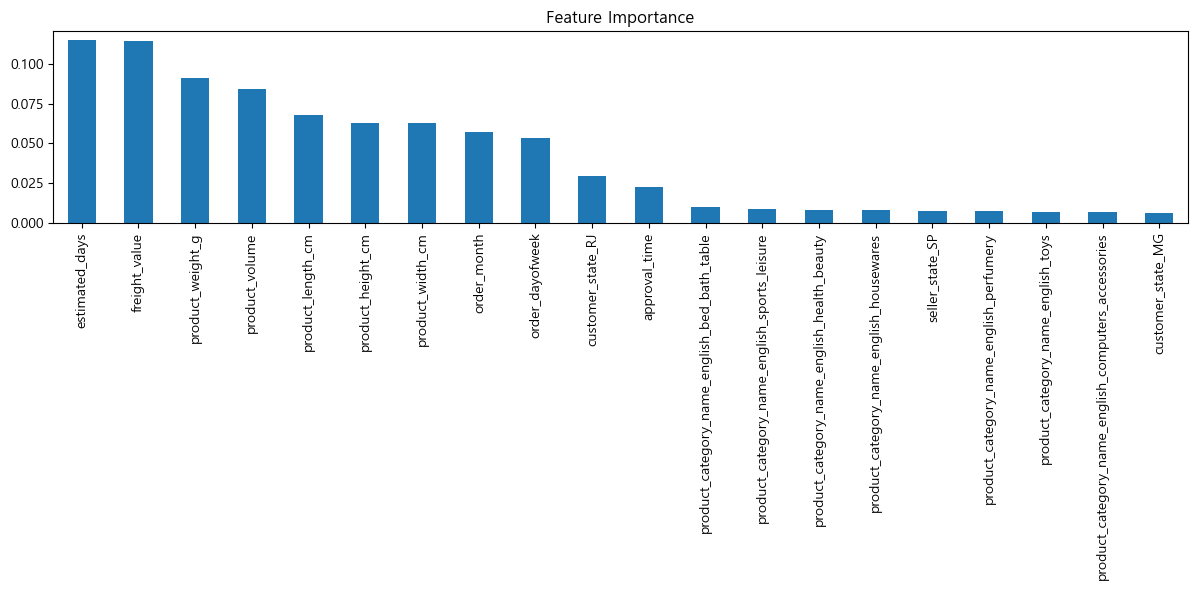

In [67]:
# 변수 중요도 추출
import matplotlib.pyplot as plt

feature_names = (
    pipeline.named_steps['preprocessor']
    .named_transformers_['cat']
    .get_feature_names_out(cat_cols).tolist() + num_cols
)

importances = pd.Series(
    pipeline.named_steps['model'].feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print(importances.head(20))

# 시각화
plt.figure(figsize=(12, 6))
importances.head(20).plot(kind='bar')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

#여기서 seller_state_SP, customer_state_RJ 같은 특정 지역이 상위에 뜨면 "이 지역이 지연에 가장 큰 영향을 준다" 는 인사이트를 뽑을 수 있어요!

In [24]:

# 조합별 평균 지연일수
combo_delay_cnt = df.groupby(['seller_state', 'customer_state'])['delivery_delay_days'].agg(['mean', 'count']).reset_index()
combo_delay_cnt.columns = ['seller_state', 'customer_state', 'avg_delay', 'count']
combo_delay_cnt = combo_delay_cnt.sort_values('avg_delay', ascending=False)
print(combo_delay_cnt.head(20))



    seller_state customer_state  avg_delay  count
0             AM             AL  38.000000      1
166           SC             GO  32.500000      4
42            GO             RJ  31.333333      3
78            MG             PI  31.000000      1
33            ES             PA  25.000000      1
1             BA             AC  24.000000      1
164           SC             CE  23.500000      4
163           SC             BA  23.444444      9
16            CE             RJ  23.000000      1
151           RS             DF  22.000000      2
17            DF             BA  22.000000      2
56            MA             PB  22.000000      1
138           RJ             RN  21.333333      3
146           RN             CE  20.000000      1
18            DF             CE  18.500000      4
133           RJ             PA  18.000000      2
126           RJ             DF  17.750000     12
70            MG             GO  17.400000      5
106           PR             ES  16.777778      9


In [25]:
# 타겟 구간 설정
df_clean['delay_class'] = pd.cut(df_clean['delivery_delay_days'],
                            bins=[0, 3, 7, 14, 50],
                            labels=['단기(1~3일)', '중기(4~7일)', '장기(8~14일)', '심각(15일~)'])

print(df_clean['delay_class'].value_counts())

delay_class
단기(1~3일)     2106
중기(4~7일)     2004
장기(8~14일)    1617
심각(15일~)     1101
Name: count, dtype: int64


In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', 'passthrough', num_cols)
])


features = [
    'seller_state',
    'customer_state',
    'same_state',
    'freight_value',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm',
    'product_category_name_english',
    'estimated_days',
    'approval_time',
    'product_volume',
    'order_month',
    'order_dayofweek'
]

cat_cols = ['seller_state', 'customer_state', 'product_category_name_english']
num_cols = ['same_state', 'freight_value', 'product_weight_g', 'product_length_cm',
            'product_height_cm', 'product_width_cm', 'estimated_days',
            'approval_time', 'product_volume', 'order_month', 'order_dayofweek']


y = df_clean['delay_class']
X = df_clean[features].fillna(df_clean[features].median(numeric_only=True))

pipeline_clf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=300, max_depth=None, min_samples_split=2, random_state=42, n_jobs=-1))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline_clf.fit(X_train, y_train)
y_pred = pipeline_clf.predict(X_test)

print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(classification_report(y_test, y_pred))

Accuracy: 0.4356
              precision    recall  f1-score   support

    단기(1~3일)       0.47      0.54      0.50       426
    심각(15일~)       0.47      0.27      0.35       231
   장기(8~14일)       0.34      0.30      0.32       307
    중기(4~7일)       0.44      0.52      0.48       402

    accuracy                           0.44      1366
   macro avg       0.43      0.41      0.41      1366
weighted avg       0.43      0.44      0.43      1366



In [37]:
print(df_clean['delay_class'].value_counts())

delay_class
단기(1~3일)     2106
중기(4~7일)     2004
장기(8~14일)    1617
심각(15일~)     1101
Name: count, dtype: int64


In [38]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# XGBoost는 문자열 라벨 못 받아서 인코딩 필요
le = LabelEncoder()
y_encoded = le.fit_transform(df_clean['delay_class'])

X = df_clean[features].fillna(df_clean[features].median(numeric_only=True))
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

pipeline_xgb_clf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1))
])

pipeline_xgb_clf.fit(X_train, y_train)
y_pred = pipeline_xgb_clf.predict(X_test)

print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.4034
              precision    recall  f1-score   support

    단기(1~3일)       0.42      0.47      0.45       426
    심각(15일~)       0.41      0.29      0.34       231
   장기(8~14일)       0.35      0.29      0.32       307
    중기(4~7일)       0.41      0.48      0.44       402

    accuracy                           0.40      1366
   macro avg       0.40      0.38      0.39      1366
weighted avg       0.40      0.40      0.40      1366

